**Employee Performance Analysis**

**Objective**:

Analyze employee performance data to identify:

* Top-performing employees.
* Department productivity.
* Salary vs performance trends.
* Attendance impact on performance.
* Employee satisfaction insights.

In [1]:
#Import Dataset in Python
import pandas as pd
df=pd.read_csv("employee_performance.csv")
print(df.head())
print(df.info())

  employee_id    employee_name  gender  age       city department  \
0     EMP0001   Jessica Clarke  Female   47  Hyderabad         HR   
1     EMP0002     Sandra Woods    Male   44       Pune      Sales   
2     EMP0003    Stephen Wells  Female   50     Mumbai         HR   
3     EMP0004      Amber Giles    Male   33    Chennai         IT   
4     EMP0005  Amanda Williams  Female   57  Hyderabad      Sales   

                         job_role education_level  experience_years  salary  \
0                       Recruiter         Masters                25   90313   
1                 Sales Executive             MBA                16  113560   
2                    HR Executive             MBA                19   47826   
3               Software Engineer         Masters                 1  117188   
4  Business Development Executive         Masters                20  140208   

   attendance_percentage  projects_completed  overtime_hours  training_hours  \
0                  65.23      

Data Cleaning

In [2]:
#Checking missing values
print(df.isnull().sum())

employee_id              0
employee_name            0
gender                   0
age                      0
city                     0
department               0
job_role                 0
education_level          0
experience_years         0
salary                   0
attendance_percentage    0
projects_completed       0
overtime_hours           0
training_hours           0
job_satisfaction         0
performance_score        0
promotion                0
dtype: int64


In [3]:
## Convert all column names to lowercase
df.columns = df.columns.str.lower()
print(df.columns)
df.head()

Index(['employee_id', 'employee_name', 'gender', 'age', 'city', 'department',
       'job_role', 'education_level', 'experience_years', 'salary',
       'attendance_percentage', 'projects_completed', 'overtime_hours',
       'training_hours', 'job_satisfaction', 'performance_score', 'promotion'],
      dtype='object')


,employee_id,employee_name,gender,age,city,department,job_role,education_level,experience_years,salary,attendance_percentage,projects_completed,overtime_hours,training_hours,job_satisfaction,performance_score,promotion
0,EMP0001,Jessica Clarke,Female,47,Hyderabad,HR,Recruiter,Masters,25,90313,65.23,6,40,83,High,7.41,No
1,EMP0002,Sandra Woods,Male,44,Pune,Sales,Sales Executive,MBA,16,113560,98.50,14,28,94,Medium,9.56,Yes
2,EMP0003,Stephen Wells,Female,50,Mumbai,HR,HR Executive,MBA,19,47826,95.98,5,12,36,Low,7.86,No
3,EMP0004,Amber Giles,Male,33,Chennai,IT,Software Engineer,Masters,1,117188,81.17,15,10,102,High,8.12,No
4,EMP0005,Amanda Williams,Female,57,Hyderabad,Sales,Business Development Executive,Masters,20,140208,73.97,12,33,56,Medium,8.07,No


In [4]:
#Removing duplicates
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis (EDA)

In [5]:
#Average Performance Score
mean=df['performance_score'].mean()
print(round(mean,2))

7.3


Overall employee performance in the company is high and positive.

In [6]:
#Top Performing Departments
dept_perf=round((df.groupby('department')['performance_score'].mean().sort_values(ascending=False)),2)
print(dept_perf)

department
Sales         7.46
HR            7.33
Operations    7.33
Marketing     7.30
Finance       7.19
IT            7.16
Name: performance_score, dtype: float64


In [7]:
#Salary vs Performance
print(df[['salary','performance_score']].corr())

                     salary  performance_score
salary             1.000000          -0.094665
performance_score -0.094665           1.000000


Store Data in SQL

In [8]:
#connecting to SQL server
import mysql.connector


host="127.0.0.1"
port=3306
username="root"
password="root"
database="employee_analysis"

from sqlalchemy import create_engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")
print("Successfully connected")

Successfully connected


In [9]:
#Load DataFrame into MySQL
table_name = "employees"

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'employees' in database 'employee_analysis'.


Visualization in Python

In [10]:
#Importing Data Visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns
print("import successfull")

import successfull


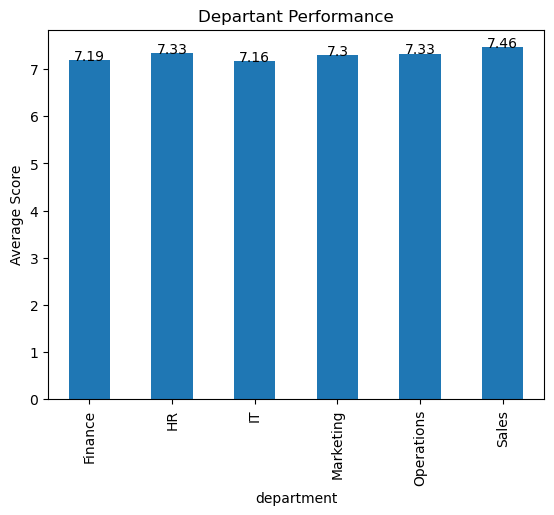

In [11]:
#Department Performance Chart
dept_perf=df.groupby('department')['performance_score'].mean()

dept_perf.plot(kind='bar')

for i, value in enumerate(dept_perf):
    plt.text(i, value, round(value, 2), ha='center')

plt.title('Departant Performance')
plt.ylabel('Average Score')
plt.show()

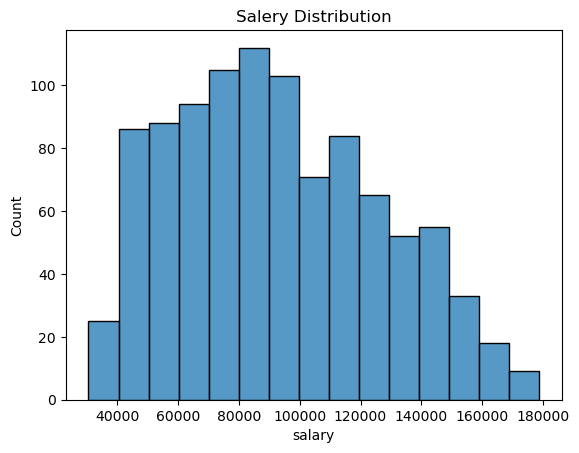

In [12]:
#Salary Distribution
sns.histplot(df['salary'])

plt.title('Salery Distribution')
plt.show()

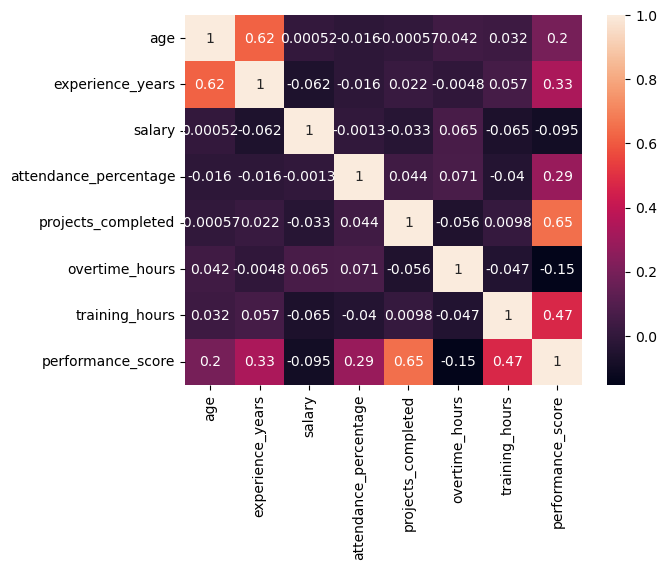

In [13]:
#Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()